In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# mplsoccer 의 statsbomb 모듈 
from mplsoccer import Sbopen, Pitch
# parser 객체를 인스턴스화
parser = Sbopen()

df_competition = parser.competition()
# df_competition.info()

# df_competition FIFA WORLD CUP의 이름과 ID를 파악하고 df_worldcup 
df_competition[["competition_id","season_id","competition_name","season_name"]].head(50)



,competition_id,season_id,competition_name,season_name
0,9,281,1. Bundesliga,2023/2024
1,9,27,1. Bundesliga,2015/2016
2,1267,107,African Cup of Nations,2023
3,16,4,Champions League,2018/2019
4,16,1,Champions League,2017/2018
5,16,2,Champions League,2016/2017
6,16,27,Champions League,2015/2016
7,16,26,Champions League,2014/2015
8,16,25,Champions League,2013/2014
9,16,24,Champions League,2012/2013


In [3]:
# 대한민국 경기 목록만 찾아오기
df_matches = parser.match(competition_id=43, season_id=106)
df_matches[['home_team_id','home_team_name','away_team_id','away_team_name']].head(40) # 이렇게 해서 대한민국의 id 와 name 형식을 파악

# 조건식 구조
df_kor_matches = df_matches[(df_matches['home_team_name'] == 'South Korea') | (df_matches['away_team_name'] == 'South Korea')]

# 대한민국 경기만 나오도록 설정
df_kor_matches[['match_id','home_team_id','home_team_name','away_team_id','away_team_name']]

,match_id,home_team_id,home_team_name,away_team_id,away_team_name
35,3857287,783,Uruguay,791,South Korea
48,3869253,781,Brazil,791,South Korea
57,3857299,791,South Korea,4885,Ghana
63,3857262,791,South Korea,780,Portugal


In [9]:
# 경기 이벤트 데이터 불러오기
df_event, df_realted, df_freeze, df_tactics = parser.event(3857287)

# 대한민국 데이터만 필터링 (대괄로 감싸는건 필수)
df_kor_event = df_event[df_event['team_name'] == 'South Korea']

# 이벤트 개수 확인
print(len(df_kor_event))


1578


In [8]:
# 교체 발생 필터링
kor_sub_events = df_kor_event[df_kor_event['type_name'] == 'Substitution']

# 첫 교체 시간 구하기
first_sub_min = kor_sub_events.iloc[0]['minute']

print(f"첫 교체 시간: {first_sub_min}분")


첫 교체 시간: 73분


In [12]:
passes = df_kor_event[
    (df_kor_event['minute'] < first_sub_min) &
    (df_kor_event['type_name'] == 'Pass') &
    (df_kor_event['outcome_name'].isna())
]


In [ ]:
# 대한민국 선수별 평균 좌표 계산하기
kor_player_coords = passes.groupby('player_name')[['x', 'y']].mean().reset_index()

print(f'대한민국 선발 인원수: {len(kor_player_coords)}명')

대한민국 선발 인원수: 11명


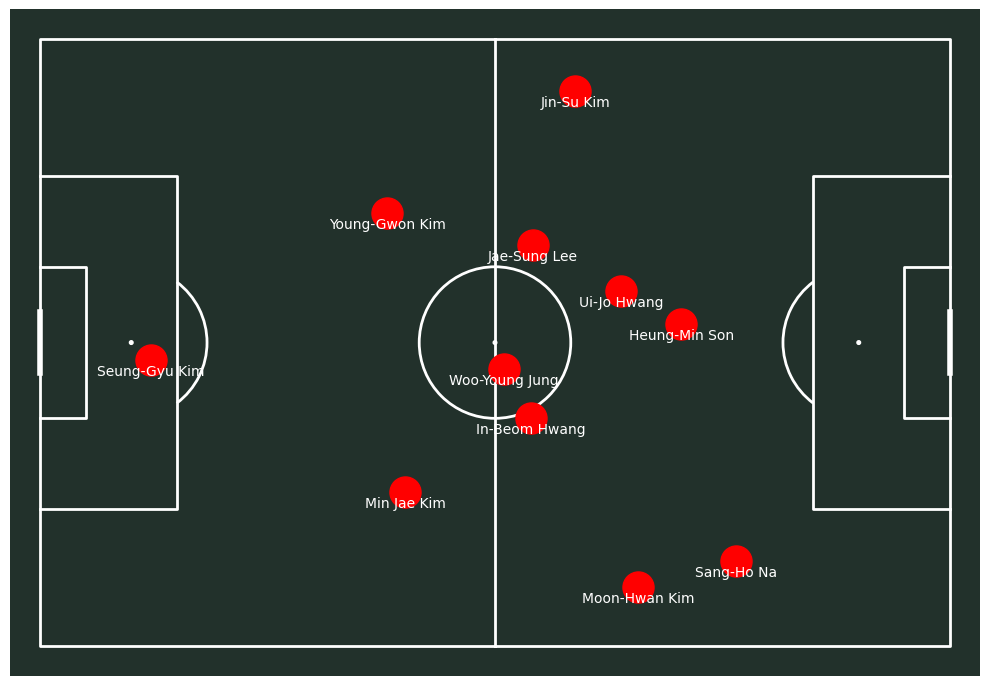

In [18]:
pitch = Pitch(pitch_type='statsbomb' , pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(10,7))

# 1. 대한민국 (붉은 점 찍기)
pitch.scatter(
    kor_player_coords['x'], 
    kor_player_coords['y'], 
    s=500, 
    color='red', 
    ax=ax
    )

# 2. 이름 표시 (반복문으로 채우기)
for idx, row in kor_player_coords.iterrows():
    pitch.annotate(
        text=row['player_name'],
        xy=(row['x'], row['y'] + 2),
        c='white', ha='center', ax= ax
    )